In [3276]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [3277]:
path_port_serial = "/dev/ttyUSB1"

In [3278]:
#l = serial.Serial()
#l.port=path_port_serial
#l.baudrate = 115200
#l.bytesize = 8
#l.open()
#l.write(bytearray([2]))
#l.close()



In [3279]:
import random as rd
import time

In [3280]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
        print(f'{X[i][j]:d}',end=' ')
    print()

In [3281]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(BitsPorSimbolo),1*9**(BitsPorSimbolo))
      Bin[i][j] = rd.randint(1*(BitsPorSimbolo),1*9**(BitsPorSimbolo))
  return [Ain,Bin]

In [3282]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [3283]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [3284]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [3285]:
def send_matrix(X,input,flag,k=0):
  file = open(f"teste{input}.txt","+w")


  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  #fs = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  fs = 500
  s.open()
  s.write(bytearray([255]))
  time.sleep(1/fs)
  s.write(bytearray([255]))
  time.sleep(1/fs)
  #file.write(f"assign {input}[{0}] = "+"8'b"+str(11111111)+";\n")
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):

      if(flag):
        s.write(bytearray([X[j][i]]))
      else:
        s.write(bytearray([0]))

      #s.write(bytearray([0]))
      #print(X[j][i])
      time.sleep(1/fs)
    #print('0b'+strbin,i)
    #print(int('0b'+strbin,2))
    #file.write(f"assign {input}[{i+1}] = "+"8'b"+strbin+";\n")
    #  time.sleep(1/Fs)  
  if(k):
    s.write(bytearray([255]))
    time.sleep(1/fs)
    s.write(bytearray([255]))
    time.sleep(1/fs)
  else:
    #s.write(bytearray([255]))
    #time.sleep(1/fs)
    #s.write(bytearray([255]))
    #time.sleep(1/fs)
    s.write(bytearray([0]))
    time.sleep(1/fs)
    s.write(bytearray([0]))
    time.sleep(1/fs)
  s.close()  
  #file.close()
 

In [3286]:
#M[0]@M[1]

In [3287]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
print_matrix(M[1])


7 4 7 1 
9 8 4 1 
8 7 1 5 
9 7 2 7 


In [3288]:

#M1 = np.array([[5,7,8],[9,8,7],[1,5,5]])
#M2 = np.array([[7,5,10],[8,8,9],[1,9,6]])

In [3289]:
#M = [M1,M2]

In [3290]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))


In [3292]:
for i in range(5):
    print("Matriz -----------------------",i,"--------------------------")
    M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix(M_p[0],"INPUT_A1",1,k=1)
    send_matrix(M_p[1],"INPUT_B1",1,k=0)
    time.sleep(5)
    print(M[0]@M[1])


Matriz ----------------------- 0 --------------------------
[[126 104  91  96]
 [ 94  84  73  76]
 [ 83  88  76  77]
 [ 77  56  57  49]]
Matriz ----------------------- 1 --------------------------
[[137 123 156  49]
 [ 90 117  82  62]
 [ 91  55  80  36]
 [ 60  84  76  29]]
Matriz ----------------------- 2 --------------------------
[[ 46  54  89  50]
 [ 64  61  75  98]
 [ 67  70 104  87]
 [ 70  61 117  94]]
Matriz ----------------------- 3 --------------------------
[[ 91  87 102  43]
 [123 111  90 134]
 [116 105 103  93]
 [ 83  78  56  99]]
Matriz ----------------------- 4 --------------------------


M_p[0]@

In [ ]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
    M_p = shiftMatrixSystolic(M[0],M[1])
    print(M[0]@M[1])
    send_matrix(M_p[0],"INPUT_A1",1,k=1)
    send_matrix(M_p[1],"INPUT_B1",1,k=1)

    #time.sleep(10)


Matriz ----------------------- 0 --------------------------
[[200 130 152 149]
 [214 142 164 156]
 [196 124 150 152]
 [153 121 115  86]]


In [ ]:
M[0]

array([[8, 9, 3, 6],
       [8, 2, 8, 8],
       [8, 2, 8, 6],
       [5, 4, 1, 9]])

In [ ]:
M[1]

array([[7, 5, 4, 7],
       [7, 3, 6, 6],
       [9, 3, 8, 9],
       [9, 9, 7, 2]])

In [ ]:
M[0]@M[1]

array([[200, 130, 152, 149],
       [214, 142, 164, 156],
       [196, 124, 150, 152],
       [153, 121, 115,  86]])

In [ ]:
M[1]@M[0]

array([[163, 109, 100, 169],
       [158, 105,  99, 156],
       [205, 139, 124, 207],
       [210, 121, 157, 186]])

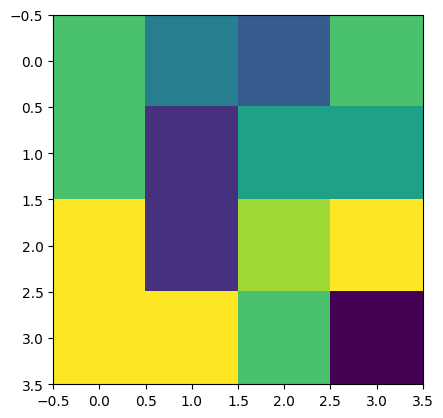

In [ ]:
plt.imshow(M[1])

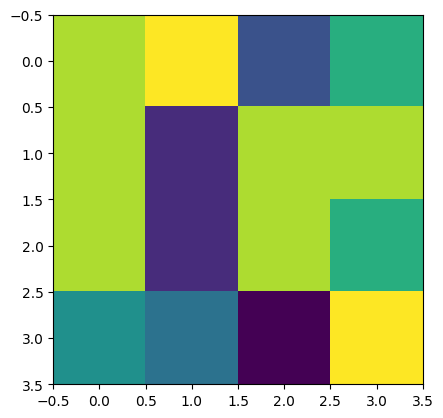

In [ ]:
plt.imshow(M[0])

In [ ]:
M[0]@M[1]

array([[200, 130, 152, 149],
       [214, 142, 164, 156],
       [196, 124, 150, 152],
       [153, 121, 115,  86]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [ ]:
M[1]@M[0]

array([[163, 109, 100, 169],
       [158, 105,  99, 156],
       [205, 139, 124, 207],
       [210, 121, 157, 186]])

In [ ]:
M[0]@M[1]

array([[200, 130, 152, 149],
       [214, 142, 164, 156],
       [196, 124, 150, 152],
       [153, 121, 115,  86]])

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 8, 9, 3, 6],
        [0, 0, 8, 2, 8, 8, 0],
        [0, 8, 2, 8, 6, 0, 0],
        [5, 4, 1, 9, 0, 0, 0]]),
 array([[0, 0, 0, 8, 8, 8, 5],
        [0, 0, 9, 2, 2, 4, 0],
        [0, 3, 8, 8, 1, 0, 0],
        [6, 8, 6, 9, 0, 0, 0]]))

In [ ]:
#M = create_matrix(Din = 16, PorSimbolo=1)

In [ ]:
M[0]@M[1]

array([[200, 130, 152, 149],
       [214, 142, 164, 156],
       [196, 124, 150, 152],
       [153, 121, 115,  86]])

In [ ]:
M

[array([[8, 9, 3, 6],
        [8, 2, 8, 8],
        [8, 2, 8, 6],
        [5, 4, 1, 9]]),
 array([[7, 5, 4, 7],
        [7, 3, 6, 6],
        [9, 3, 8, 9],
        [9, 9, 7, 2]])]

In [ ]:
M_p[0]

array([[0, 0, 0, 8, 9, 3, 6],
       [0, 0, 8, 2, 8, 8, 0],
       [0, 8, 2, 8, 6, 0, 0],
       [5, 4, 1, 9, 0, 0, 0]])

In [ ]:
M_p[1]

array([[0, 0, 0, 8, 8, 8, 5],
       [0, 0, 9, 2, 2, 4, 0],
       [0, 3, 8, 8, 1, 0, 0],
       [6, 8, 6, 9, 0, 0, 0]])

In [ ]:
def send_matrix1(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  file.write(f'{0XFF:02X}'+"\n")
  file.write(f'{0XFF:02X}'+"\n")
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()
  file.write(f'{0XFF:02X}'+"\n")
  file.write(f'{0XFF:02X}'+"\n")
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix1(M_p[0],"INPUT_A1",0)
    send_matrix1(M_p[1],"INPUT_B1",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [ ]:
len(str("0000000000000009"))*4


64

In [ ]:
M[0]@M[1]

array([[200, 130, 152, 149],
       [214, 142, 164, 156],
       [196, 124, 150, 152],
       [153, 121, 115,  86]])

In [ ]:
M_p[1]

array([[0, 0, 0, 7, 7, 9, 9],
       [0, 0, 5, 3, 3, 9, 0],
       [0, 4, 6, 8, 7, 0, 0],
       [7, 6, 9, 2, 0, 0, 0]])

In [ ]:
M_p[0]

array([[0, 0, 0, 8, 9, 3, 6],
       [0, 0, 8, 2, 8, 8, 0],
       [0, 8, 2, 8, 6, 0, 0],
       [5, 4, 1, 9, 0, 0, 0]])

In [ ]:
print_matrix(M[0]@M[1])

200 130 152 149 
214 142 164 156 
196 124 150 152 
153 121 115 86 


In [ ]:
M[0]@M[1]

array([[200, 130, 152, 149],
       [214, 142, 164, 156],
       [196, 124, 150, 152],
       [153, 121, 115,  86]])

In [ ]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 8, 9, 3, 6],
        [0, 0, 8, 2, 8, 8, 0],
        [0, 8, 2, 8, 6, 0, 0],
        [5, 4, 1, 9, 0, 0, 0]]),
 array([[0, 0, 0, 7, 7, 9, 9],
        [0, 0, 5, 3, 3, 9, 0],
        [0, 4, 6, 8, 7, 0, 0],
        [7, 6, 9, 2, 0, 0, 0]])]

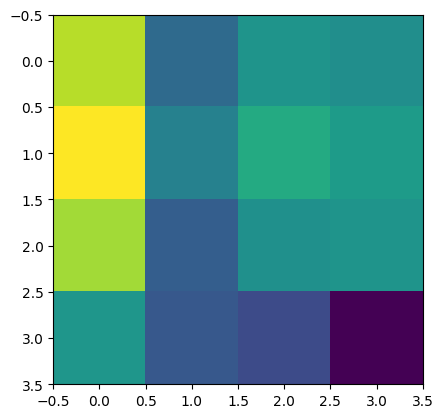

In [ ]:
plt.imshow(M[0]@M[1])

plt.show()

In [ ]:

#for i in range(100):
#    print("----------------------",i,"--------------------------")
#    M_p = shiftMatrixSystolic(M[0],M[1])
#    #Bin = M[1]
#    send_matrix(M_p[0],"INPUT_A1",0)
#    send_matrix(M_p[1],"INPUT_B1",0)
#    
#    break
#    time.sleep(10)
#
#send_matrix(Bin)

In [ ]:
M[0]

array([[8, 9, 3, 6],
       [8, 2, 8, 8],
       [8, 2, 8, 6],
       [5, 4, 1, 9]])

In [ ]:
M[1]

array([[7, 5, 4, 7],
       [7, 3, 6, 6],
       [9, 3, 8, 9],
       [9, 9, 7, 2]])

In [ ]:
M[0]@M[1]

array([[200, 130, 152, 149],
       [214, 142, 164, 156],
       [196, 124, 150, 152],
       [153, 121, 115,  86]])

In [ ]:
s = serial.Serial()

s.port = path_port_serial
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [ ]:
i =1
s.write(bytearray([int(i)]))


1

In [ ]:
serial.Serial()

Serial<id=0x7fb7a5f39d20, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)